In [2]:
%load_ext autoreload
%autoreload 2
import torch
from torch import nn
from Systems import Rossler
import numpy as np
from NN import Main_Network, NN
import matplotlib.pyplot as plt
from Dataset import DataSet
from Normalizer import Normalizer
from Trainer import Trainer
import scipy.io as spio
from Observer import System_z, Observer
import torch.nn.functional as F

ValueError: x and y must have same first dimension, but have shapes (50,) and (0,)

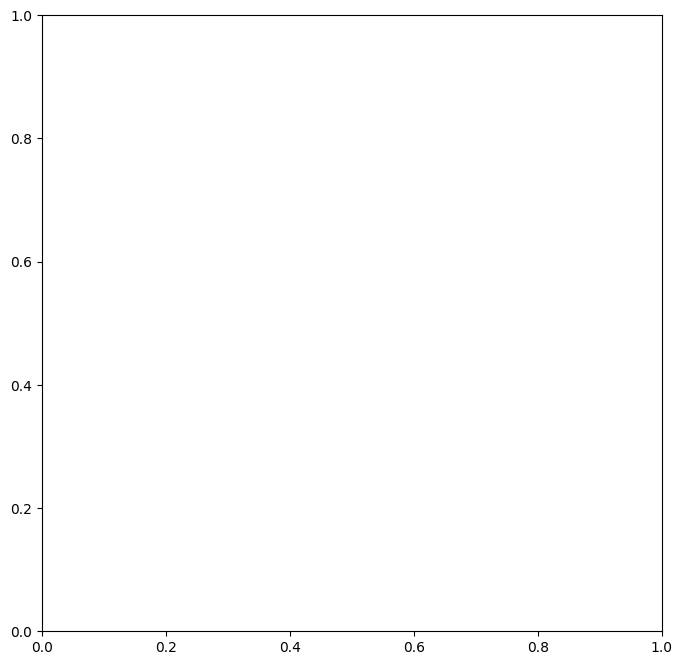

In [13]:
#------------- Rössler ------------- 
a0 = 0.2
b0 = 0.2
c0 = 5.7
limits = np.array([[-1,1], [-1,1], [-1,1]])    # Sample space

# A and B matricies 
M = np.array([[-2.12116939,  2.73877907, -0.75338041,  3.13947511,  1.00581224,
        -5.34548426, -5.34544528],
    [-5.91811463, -1.99160105, -0.26953991,  0.45654273, -0.56750459,
        -3.79023002, -3.00480715],
    [-1.27814843, -2.08375366, -2.60781906, -4.11186517,  0.33087248,
        0.08191241, -2.81998688],
    [ 0.69080313,  2.00687664,  3.02478991, -3.53231915, -0.89704804,
        -5.19153027,  3.16796666],
    [-1.16566857, -0.53979687, -0.30300461, -3.79753229, -2.7939018 ,
        -0.30176078, -2.61480264],
    [ 2.97899741,  3.97265572, -2.04951338, -1.08716448, -0.98741222,
        -4.7047881 , -1.38218644],
    [ 0.95887295,  0.43056828, -1.39564903, -3.18608794,  3.74388666,
        -3.88509855, -3.07468653]])

K = np.ones([7,1])

rossler = Rossler(a0, b0, c0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N = 1000
a = 0
b = 50

model_data = torch.load('models/rossler_T_inverse_lr0.001_batch32_epoch15', map_location=torch.device('cpu'))
num_hidden = model_data['config']['num_hidden']
hidden_size = model_data['config']['hidden_size']
x_size = model_data['config']['x_size']
z_size = model_data['config']['z_size']
activation = model_data['config']['activation']
normalizer = model_data['config']['normalizer']
T_inv_net = NN(num_hidden, hidden_size, z_size, x_size, activation, normalizer=normalizer).to(device)
T_inv_net.load_state_dict(model_data['model'])
T_inv_net.eval()

observer2 = Observer(rossler, M, K, T_inv_net, a, b, N, init_z_zero=True)

initial_conds = np.arange(0.1, 5.1, 0.1)
MAE_x_list_new = []
MAE_y_list_new = []

# for ic in initial_conds:
#     ic = np.array([[ic, ic, ic]])
#     #sys_dim5.toggle_noise()
#     x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
#     MAE_x = np.mean(error[0][:,0])
#     MAE_y = np.mean(error[0][:,1])
#     MAE_x_list_new.append(MAE_x)
#     MAE_y_list_new.append(MAE_y)

fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(initial_conds, MAE_x_list_new, label = 'MAE x')
plt.plot(initial_conds, MAE_y_list_new, label = 'MAE y')
plt.legend()
plt.title('New Method')
plt.xlabel('Initial (x0,y0)')
plt.ylabel('Mean Absolute Error')
plt.show()

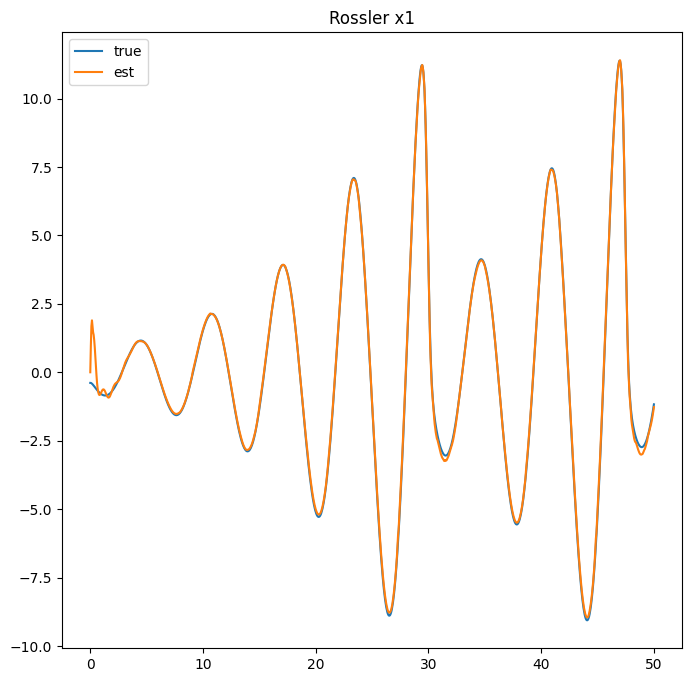

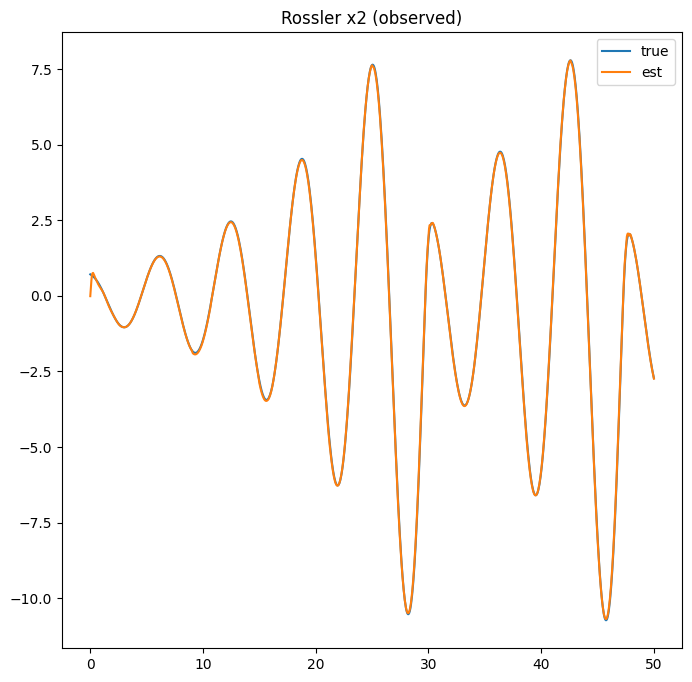

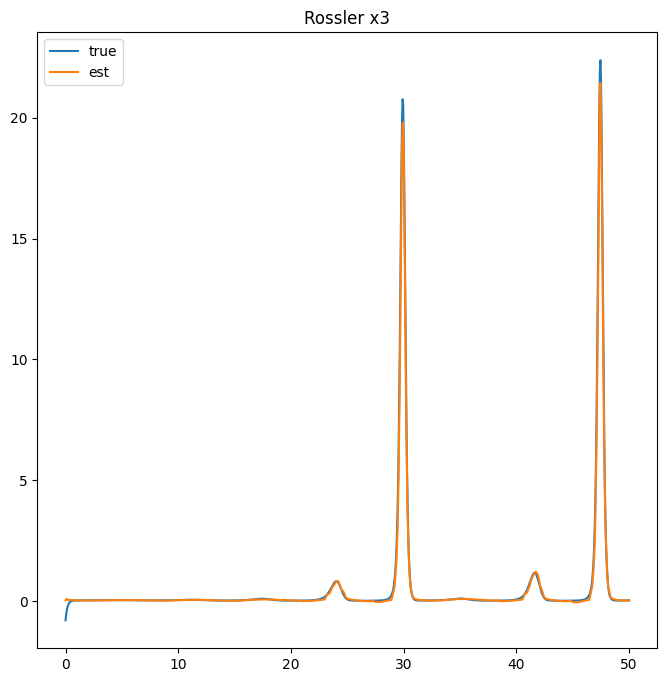

In [12]:
ic = np.array([[0.5, 0.5, 0.5]])
ic = np.random.uniform(-1,1,[1,3])

x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(t, x[:,0], label = 'true')
plt.plot(t, x_hat[:,0], label = 'est')
plt.title('Rossler x1')
plt.legend()
plt.show()

fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(t, x[:,1], label = 'true')
plt.plot(t, x_hat[:,1], label = 'est')
plt.title('Rossler x2 (observed)')
plt.legend()

fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(t, x[:,2], label = 'true')
plt.plot(t, x_hat[:,2], label = 'est')
plt.title('Rossler x3')
plt.legend()
plt.show()

In [16]:
def eval_errors(xs, xs_predict):
    errs = np.sqrt(((xs - xs_predict) ** 2).mean(-1).mean(0))
    tot = errs.mean()
    return tot

num_ic = 1000
init_conds = np.random.uniform(-1,1,[num_ic,1,3])

x_true = np.zeros([num_ic, N+1, rossler.x_size])
x_pred = np.zeros([num_ic, N+1, rossler.x_size])

for idx, ic in enumerate(init_conds):
    x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
    x_true[idx, :,:] = x
    x_pred[idx, :,:] = x_hat


print(eval_errors(x_true, x_pred))

0.14169755347835455


In [5]:
print(x_true.shape)

(1000, 1001, 3)


In [20]:
print(T_inv_net)

NN(
  (layers): ModuleList(
    (0): Linear(in_features=7, out_features=250, bias=True)
    (1-2): 2 x Linear(in_features=250, out_features=250, bias=True)
    (3): Linear(in_features=250, out_features=3, bias=True)
  )
  (dropout): Dropout(p=0.0, inplace=False)
)
